In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

import apache_beam as beam
import numpy as np
import xarray as xr
import weatherbenchX
from weatherbenchX.data_loaders import xarray_loaders
from weatherbenchX.metrics import deterministic
from weatherbenchX.metrics import base as metrics_base
from weatherbenchX import aggregation
from weatherbenchX import weighting
from weatherbenchX import binning
from weatherbenchX import time_chunks
from weatherbenchX import beam_pipeline

def open_zarr_over_ssh(remote, path):
    """
    Opens zarr file at remote:path over SSH. It asumes zarr v3 format.
    """
    try:
        from sshfs import SSHFileSystem
        from fsspec.implementations.asyn_wrapper import AsyncFileSystemWrapper
        from zarr.storage import FsspecStore
    except ImportError as e:
        raise ImportError("sshfs, fsspec, and zarr must be installed to use open_zarr_over_ssh") from e
    
    fs = SSHFileSystem(remote)
    afs = AsyncFileSystemWrapper(fs)
    return xr.open_zarr(FsspecStore(afs, path=path), consolidated=False)


In [2]:
def scp_load(path):
    tmp = 'tmp.nc'
    !scp -r "snellius1:$path" $tmp
    ds = xr.open_dataset(tmp)
    os.remove(tmp)
    
    return ds

In [ ]:
def plot(target_chunk, prediction_chunk, title):
    fig, axs = plt.subplots(1, 3, figsize=(20,3), subplot_kw={'projection': ccrs.PlateCarree()})
    target_chunk.isel(init_time=0, lead_time=0, drop=True)['2m_temperature'].plot(ax=axs[0], vmin=240, vmax=310)
    axs[0].coastlines()
    prediction_chunk.isel(init_time=0, lead_time=0, drop=True)['2m_temperature'].plot(ax=axs[1], vmin=240, vmax=310)
    axs[1].coastlines()
    (target_chunk-prediction_chunk).isel(init_time=0, lead_time=0, drop=True)['2m_temperature'].plot(ax=axs[-1], vmin=-2, vmax=2, cmap='RdBu')
    axs[-1].coastlines()
    fig.suptitle(title+f" 2m temperature")
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, 3, figsize=(20,3), subplot_kw={'projection': ccrs.PlateCarree()})
    target_chunk.isel(init_time=0, lead_time=0, drop=True).sel(level=500)['geopotential'].plot(ax=axs[0], vmin=49000, vmax=58000)
    axs[0].coastlines()
    prediction_chunk.isel(init_time=0, lead_time=0, drop=True).sel(level=500)['geopotential'].plot(ax=axs[1], vmin=49000, vmax=58000)
    axs[1].coastlines()
    (target_chunk-prediction_chunk).isel(init_time=0, lead_time=0, drop=True).sel(level=500)['geopotential'].plot(ax=axs[-1], vmin=-1000, vmax=1000, cmap='RdBu_r')
    axs[-1].coastlines()
    fig.suptitle(title+f" 500 hPa geopotential")
    plt.tight_layout()
    plt.show()

/var/folders/l9/513m2x1n1xj1ss41yczgxvmr0000gn/T/ipykernel_43039/2211320795.py:48: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  aurora_verif_2022 = rename_z(xr.open_zarr(



Latitudes:
    * forecast: -89.75 90.0 (720 values)
    * target: -90.0 90.0 (721 values)
    * verification: 90.0 -89.75 (720 values)


Init times:
    * forecast: 2022-01-01T12:00:00.000000000 2022-12-12T00:00:00.000000000 (54 values)
    * verification: 2022-01-01T12:00:00.000000000 2022-12-31T00:00:00.000000000 (728 values)

 
2t RMSE:
    * pred vs target       : [2.4774525 2.5211632 2.5113413 2.544056  2.610415 ]
    * pred vs verification : [1.88630592 1.94815542 1.99431291 2.07565593 2.14484501]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [672.0124  687.62317 705.0886  725.55383 744.9855 ]
    * pred vs verification : [509.1154525  528.33825283 551.12159751 571.41037735 596.75886821]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]



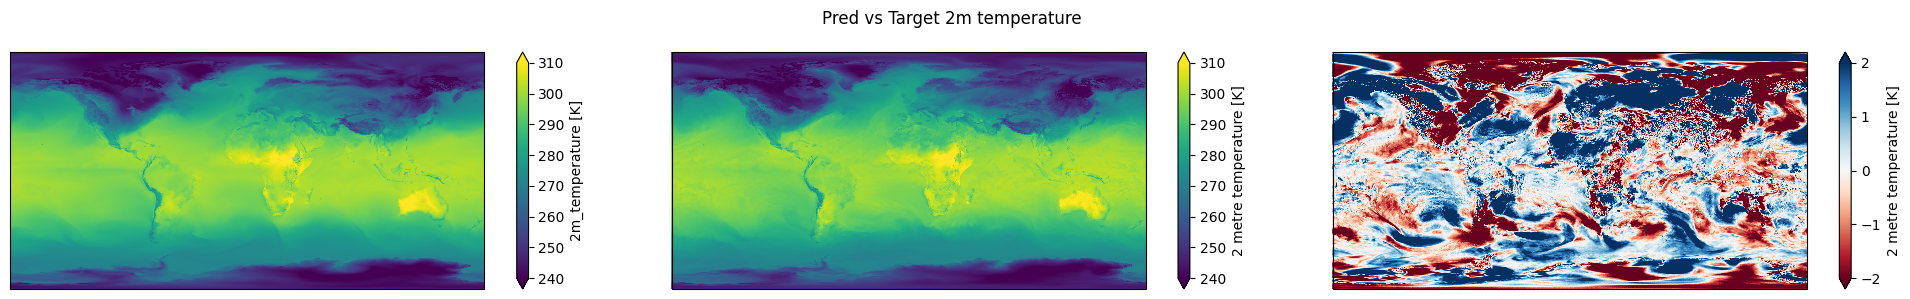

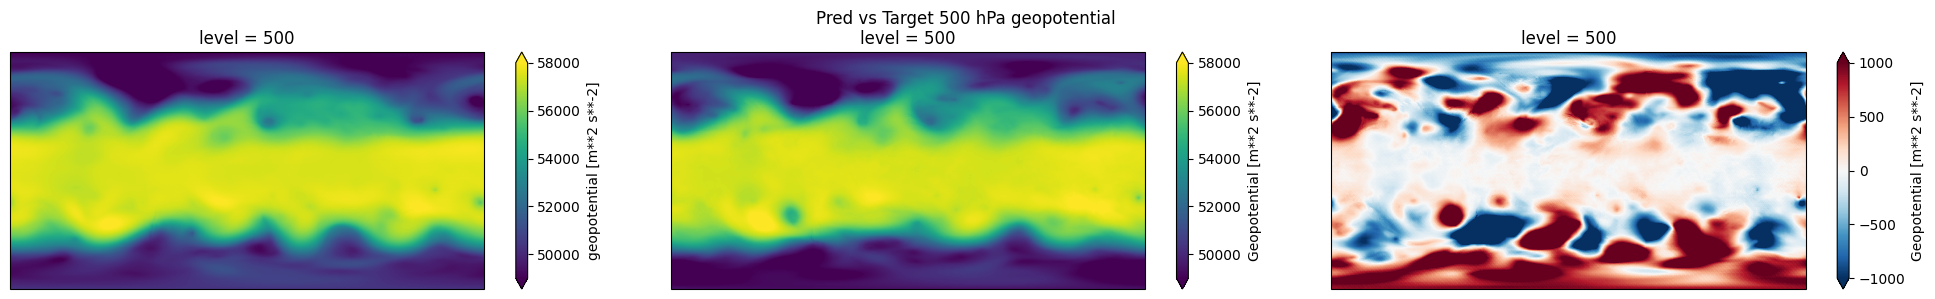

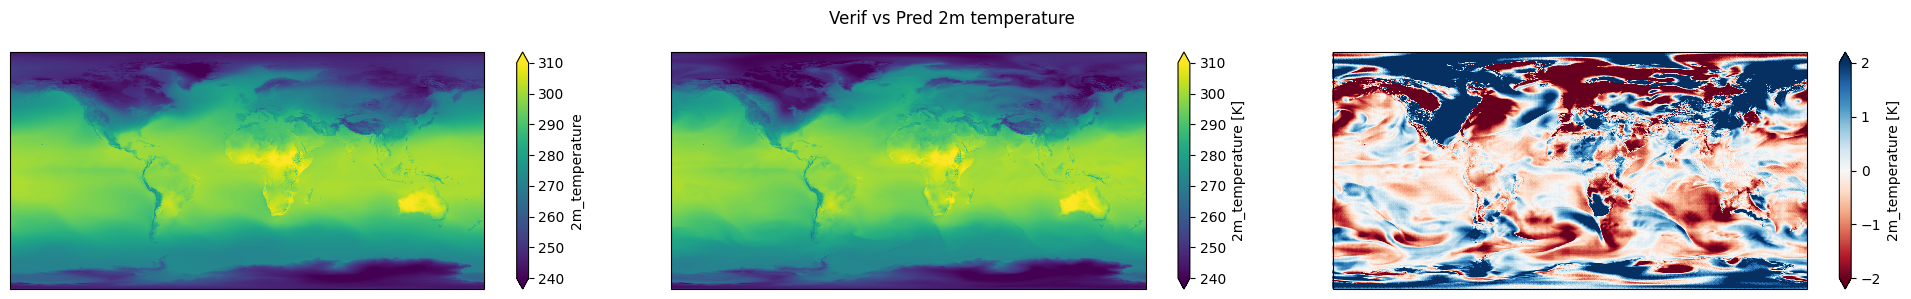

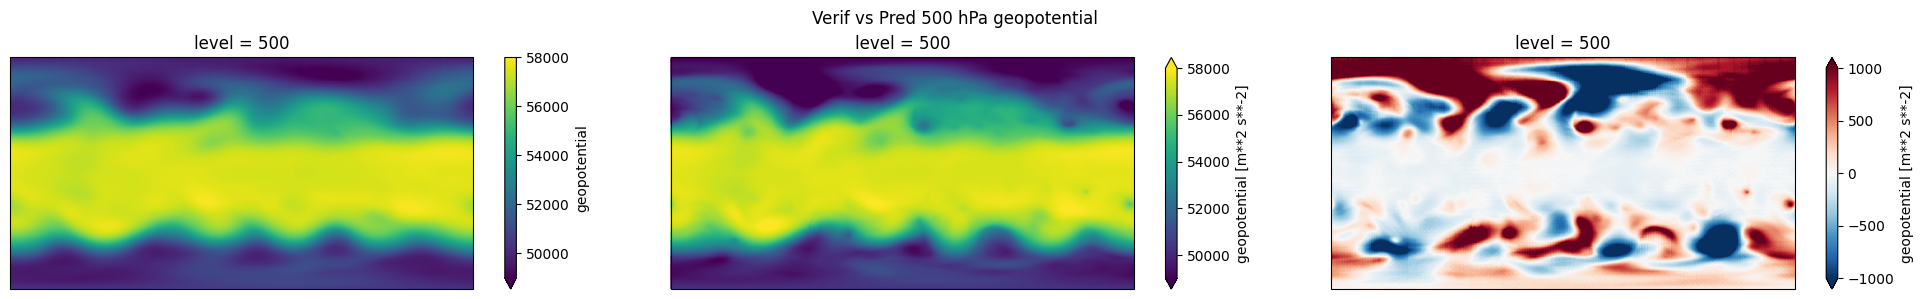

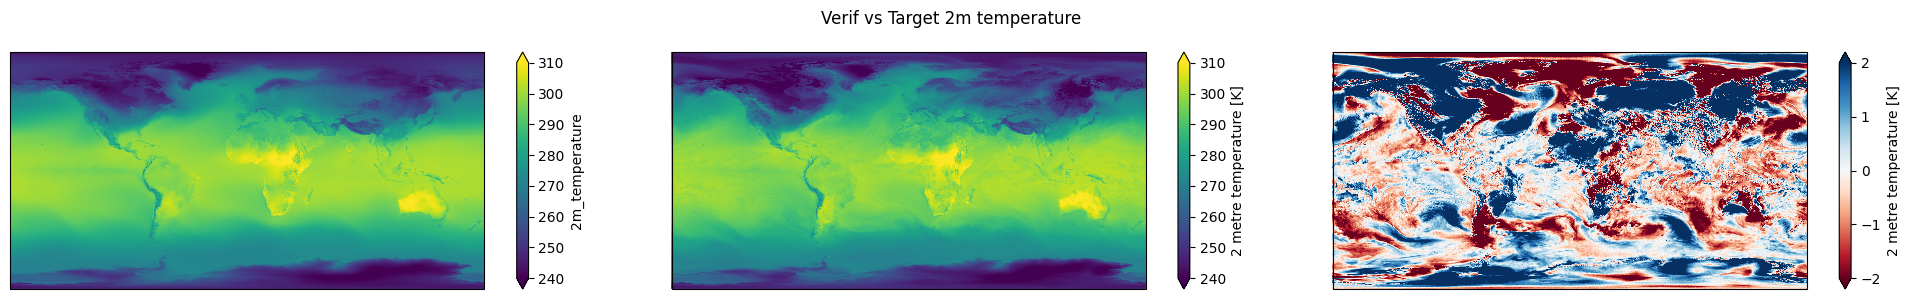

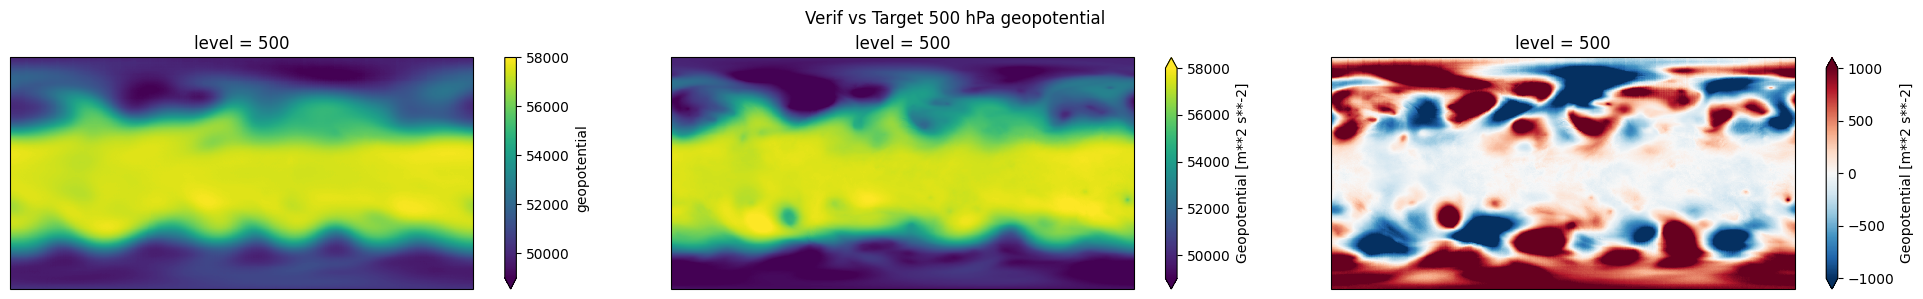

In [ ]:
variables = ['2m_temperature', 'geopotential']

forecast = open_zarr_over_ssh(
    'snellius1',
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-03_15-32-26/aurora-pretrained-from-aurora_forecasts.zarr' # pretrained, aurora code, new container, malloc stuff
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-03_15-48-54/aurora-finetuned-from-aurora_forecasts.zarr' # oper, aurora code, new container, malloc stuff
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-06_09-37-59/aurora-pretrained-from-aurora_forecasts.zarr' # pretrained, ... + batch/ds/zarr consistency stuff
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-06_13-19-02/aurora-pretrained-from-aurora_forecasts.zarr' # pretrained, ... + right static
    # '/gpfs/home3/ewalt/Xaurora/forecast.zarr' # aurora oper from rollout() (scripts/forecast_aurora_compare/main_with_xaurora_dataset.py): no crop lat in dataset, xr from function, 
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-06_15-44-08/aurora-finetuned-from-aurora_forecasts.zarr' # operational FP32
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-06_17-03-14/aurora-finetuned-from-aurora_forecasts.zarr' # operational FP32, just checking I didn't break the batch/dataset -> seems ok
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-09_14-02-44/aurora-finetuned-from-aurora_forecasts.zarr' # operational FP32, ..., no latitude crop
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-09_16-12-40/aurora-finetuned-from-aurora_forecasts.zarr' # operational: undoing env change 
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-09_16-59-45/aurora-finetuned_forecasts.zarr' # operational: back to Xaurora implem of Aurora
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-09_17-18-50/aurora-finetuned_forecasts.zarr' # operational: ..., BF16 from constructor! (B=1)
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-10_09-57-15/aurora-finetuned_forecasts.zarr', # operational: ..., full BF16 fwd, unnormalise in fwd, B=2
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-10_10-10-28/aurora-finetuned_forecasts.zarr' # operational: ..., full BF16 fwd, unnormalise OUTSIDE fwd, B=2
    #'/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-10_11-03-02/aurora-finetuned_forecasts.zarr' # operataional: bf16 backbone only, SDPA fix (https://github.com/pytorch/pytorch/issues/142228)
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-10_11-13-12/aurora-finetuned_forecasts.zarr', # same, B=3
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-10_11-23-18/aurora-finetuned_forecasts.zarr' # 15d operational
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_xaurora/forecast_2026-03-10_20-46-40/aurora-pretrained_forecasts.zarr' # pretrained, from forecast_aurora, 15d ERA5 2022
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_xaurora/forecast_2026-03-10_22-28-53/aurora-finetuned_forecasts.zarr' # operational, from forecast_aurora, 15d HRES-t0 2022
    # '/projects/prjs1808/ewalt1/Xaurora/train/16g/2026-01-30_02-40-30/forecast_2026-03-11_09-43-45/xaurora_forecasts.zarr' # Xaurora vs ERA5 2022 (short debug run)
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_10-43-32/aurora-finetuned-from-aurora_forecasts.zarr' # aurora from aurora code, oeprational, no bf16, B=1, 15d 2022 -> still a bit different
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_11-03-27/aurora-finetuned-from-aurora_forecasts.zarr' # aurora from aurora code + container/malloc, oeprational, no bf16, B=1, 15d 2022' -> similar to above
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_11-28-34/aurora-finetuned-from-aurora_forecasts.zarr' # aurora from aurora code + container/malloc, oeprational, bf16, B=2, 15d 2022 -> similar again
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_11-57-35/aurora-finetuned-no_lora-from-aurora_forecasts.zarr' # aurora from aurora code, oper. w/o LoRA + container/malloc, oeprational, bf16, B=2, 15d 2022 -> 
    '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_13-56-18/aurora-finetuned_forecasts.zarr' # operational, from xaurora code, fixed LoRA enabled
    # '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_13-59-45/aurora-finetuned-no_lora-from-aurora_forecasts.zarr' # operational, from aurora code, undo sdpa fix
)[variables]

if 'number' in forecast.coords:
    forecast = forecast.mean('number')

# target = xr.open_zarr(
#     "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr/"
# )[variables]#.sel(latitude=forecast.latitude.values)
target = open_zarr_over_ssh(
    'snellius1',
    "/projects/prjs1808/datasets/HRES_T0/datasets/hres_t0/2016-2022-6h-1440x721.zarr/",
)[variables]#.sel(latitude=forecast.latitude.values)

def rename_z(ds):
    for data_var in ds.data_vars:
        if data_var.startswith('geopotential'):
            ds = ds.rename({data_var: 'geopotential'})
    return ds
aurora_verif_2022 = rename_z(xr.open_zarr(
    "gs://weatherbench2/datasets/aurora/2022-1440x721.zarr"
))[variables]#.sel(latitude=forecast.latitude.values)

# aurora_verif_2022 = open_zarr_over_ssh(
#     'snellius1',
#     '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_11-28-34/aurora-finetuned-from-aurora_forecasts.zarr'
# )[variables]#.sel(latitude=forecast.latitude.values)


_msg = f"""
Latitudes:
    * forecast: {forecast.latitude.values[0]} {forecast.latitude.values[-1]} ({len(forecast.latitude.values)} values)
    * target: {target.latitude.values[0]} {target.latitude.values[-1]} ({len(target.latitude.values)} values)
    * verification: {aurora_verif_2022.latitude.values[0]} {aurora_verif_2022.latitude.values[-1]} ({len(aurora_verif_2022.latitude.values)} values)
"""
print(_msg)

_msg = f"""
Init times:
    * forecast: {forecast.time.values[0]} {forecast.time.values[-1]} ({len(forecast.time.values)} values)
    * verification: {aurora_verif_2022.time.values[0]} {aurora_verif_2022.time.values[-1]} ({len(aurora_verif_2022.time.values)} values)
"""
print(_msg)

target_data_loader = xarray_loaders.TargetsFromXarray(
    ds=target,
    variables=variables,
)
verif_data_loader = xarray_loaders.PredictionsFromXarray(
    ds=aurora_verif_2022,
    variables=variables,
)
prediction_data_loader = xarray_loaders.PredictionsFromXarray(
    ds=forecast,
    variables=variables,
)

forecast_init_times = forecast.time.values[:5] # 2022-01-01 to 2022-01-05
forecast_lead_times = forecast.prediction_timedelta.values[35:40] # 7 to 10 days
target_chunk = target_data_loader.load_chunk(forecast_init_times, forecast_lead_times)
prediction_chunk = prediction_data_loader.load_chunk(forecast_init_times, forecast_lead_times)

verif_init_times = forecast_init_times # aurora_verif_2022.time.values[:5]
verif_lead_times = forecast_lead_times  # aurora_verif_2022.prediction_timedelta.values[20:29] # 5 to 7 days
verif_chunk = verif_data_loader.load_chunk(verif_init_times, verif_lead_times)
verif_target_chunk = target_data_loader.load_chunk(verif_init_times, verif_lead_times)

metrics = {
  'rmse': deterministic.RMSE(),
}
aggregator = aggregation.Aggregator(
  reduce_dims=['init_time', 'latitude', 'longitude'],
  weigh_by=[weighting.GridAreaWeighting()]
)
res = aggregation.compute_metric_values_for_single_chunk(
    metrics,
    aggregator,
    prediction_chunk,
    target_chunk
)
verif_res = aggregation.compute_metric_values_for_single_chunk(
    metrics,
    aggregator,
    prediction_chunk,
    verif_chunk
)
verif_verif_res = aggregation.compute_metric_values_for_single_chunk(
    metrics,
    aggregator,
    verif_chunk,
    verif_target_chunk,
)
_msg = f""" 
2t RMSE:
    * pred vs target       : {res['rmse.2m_temperature'].values}
    * pred vs verification : {verif_res['rmse.2m_temperature'].values}
    * verif vs target      : {verif_verif_res['rmse.2m_temperature'].values}
z500 RMSE:
    * pred vs target       : {res['rmse.geopotential'].sel(level=500).values}
    * pred vs verification : {verif_res['rmse.geopotential'].sel(level=500).values}
    * verif vs target      : {verif_verif_res['rmse.geopotential'].sel(level=500).values}
"""
print(_msg)

plot(prediction_chunk, target_chunk, "Pred vs Target")
plot(verif_chunk, prediction_chunk, "Verif vs Pred")
plot(verif_chunk, verif_target_chunk, "Verif vs Target")

```
Operational from Aurora code, container v2, no BF16, 35:40 (7-10d) (5 first inits)
2t RMSE:
    * pred vs target       : [2.2821548 2.3172204 2.3553877 2.4130762 2.486824 ]
    * pred vs verification : [0.52854673 0.53402932 0.53287935 0.54459918 0.54896222]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [623.75464 641.15686 659.1908  675.4315  691.23663]
    * pred vs verification : [134.74709412 134.74820115 135.4504237  135.27545375 135.96389669]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]
 ```

Container v2 does not make a huge difference
```
Operational from Aurora code, container v1, no BF16, 35:40 (7-10d) (5 first inits)
2t RMSE:
    * pred vs target       : [2.2822976 2.317271  2.3554158 2.4130507 2.486763 ]
    * pred vs verification : [0.52857337 0.53404529 0.53291648 0.54463817 0.54902033]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [623.7186 641.1217 659.1825 675.4452 691.2606]
    * pred vs verification : [134.68976253 134.69262755 135.39945521 135.22702862 135.89823571]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]
```

BF16 SEEMS TO MAKE IT SLIGHTLY BETTER ACTUALLY! (see below)
```
Operational from Aurora code, container v1, BF16, 35:40 (7-10d) (5 first inits)
2t RMSE:
    * pred vs target       : [2.2583435 2.2945664 2.3338826 2.3918862 2.467449 ]
    * pred vs verification : [0.46261182 0.46726145 0.46736708 0.47896415 0.48312116]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [619.2605 637.2978 655.625  672.4865 688.5433]
    * pred vs verification : [117.09882961 117.31234533 118.05886971 117.96786564 118.60834898]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]
```

```
Operational from Xaurora code, container v1, BF16, 35:40 (7-10d) (5 first inits)
2t RMSE:
    * pred vs target       : [2.4774003 2.5295389 2.5202289 2.553563  2.6137204]
    * pred vs verification : [1.89231307 1.95988689 2.00431078 2.08003234 2.14332283]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [671.8969 685.9033 701.0622 719.1594 736.5121]
    * pred vs verification : [513.34461925 530.99902751 552.10470217 570.93902761 595.3831847 ]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]
```

Our Aurora operational predictions are much sharper! Perhaps we are not actually enabling LoRA. Below we show a aurora.Aurora run without LoRA -> does it look more like what we have??
```
Operational w/o LoRA from Aurora code, container v1, BF16, 35:40 (7-10d) (5 first inits)
2t RMSE:
    * pred vs target       : [2.4774525 2.5211632 2.5113413 2.544056  2.610415 ]
    * pred vs verification : [1.88630592 1.94815542 1.99431291 2.07565593 2.14484501]
    * verif vs target      : [2.18467236 2.22906624 2.27335705 2.3346737  2.41468113]
z500 RMSE:
    * pred vs target       : [672.0124  687.62317 705.0886  725.55383 744.9855 ]
    * pred vs verification : [509.1154525  528.33825283 551.12159751 571.41037735 596.75886821]
    * verif vs target      : [599.56654738 619.38434484 638.78810003 658.7249669  676.61850889]
```

/var/folders/l9/513m2x1n1xj1ss41yczgxvmr0000gn/T/ipykernel_43039/2938213103.py:15: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  aurora_verif_2022 = rename_z(xr.open_zarr(


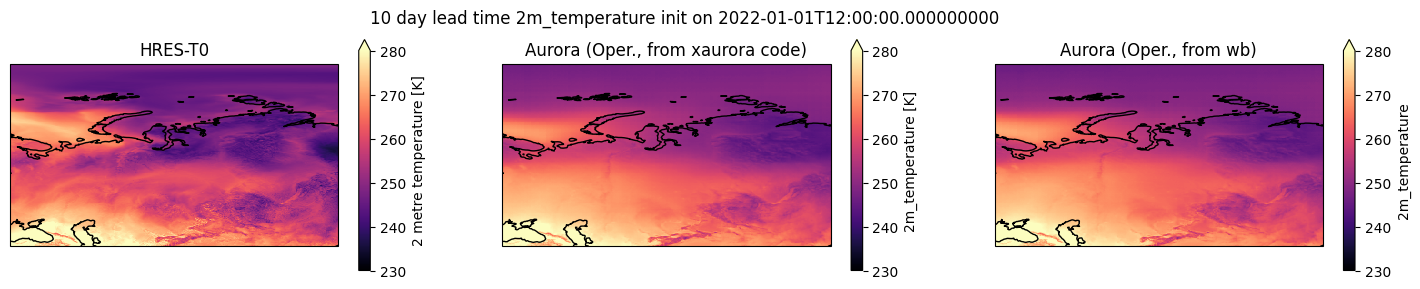

In [95]:

# Xaurora's Aurora operational
forecast = open_zarr_over_ssh(
    'snellius1',
    '/projects/prjs1808/ewalt1/Xaurora/aurora_from_aurora/forecast_2026-03-11_13-56-18/aurora-finetuned_forecasts.zarr'
)
target = open_zarr_over_ssh(
    'snellius1',
    "/projects/prjs1808/datasets/HRES_T0/datasets/hres_t0/2016-2022-6h-1440x721.zarr/",
)
def rename_z(ds):
    for data_var in ds.data_vars:
        if data_var.startswith('geopotential'):
            ds = ds.rename({data_var: 'geopotential'})
    return ds
aurora_verif_2022 = rename_z(xr.open_zarr(
    "gs://weatherbench2/datasets/aurora/2022-1440x721.zarr"
))

# plot europe + russia up to north pole
latitudes = slice(40, 90)
longitudes = slice(30, 120)

lead_time_index = (10 * 4)-1 # 10 days
init_time = forecast.time.values[0]
sel = lambda ds: (
    ds
    .sortby('latitude', ascending=True)
    .isel(prediction_timedelta=lead_time_index, drop=True)
    .sel(time=init_time, level=500)[var]
    .sel(latitude=latitudes, longitude=longitudes)
)
sel_target = lambda ds: (
    ds.sel(time=init_time+np.timedelta64(10, 'D'), level=500)[var]
    .sel(latitude=latitudes, longitude=longitudes)
)


var = '2m_temperature'

fig, axs = plt.subplots(1, 3, figsize=(18,3), subplot_kw={'projection': ccrs.PlateCarree()})
sel_target(target).plot(ax=axs[0], vmin=230, vmax=280, cmap='magma')
axs[0].set_title("HRES-T0")
axs[0].coastlines()
sel(forecast).plot(ax=axs[1], vmin=230, vmax=280, cmap='magma')
axs[1].set_title("Aurora (Oper., from xaurora code)")
axs[1].coastlines()
sel(aurora_verif_2022).plot(ax=axs[-1], vmin=230, vmax=280, cmap='magma')
axs[-1].set_title("Aurora (Oper., from wb)")
axs[-1].coastlines()

fig.suptitle(f"10 day lead time {var} init on {str(init_time)}")
plt.show()